Random Forest
Doğruluk Oranı (Accuracy): % 99.44
ROC AUC Skoru: 0.9997
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99       174
         1.0       1.00      1.00      1.00       719

    accuracy                           0.99       893
   macro avg       0.99      0.99      0.99       893
weighted avg       0.99      0.99      0.99       893



Decision Tree
Doğruluk Oranı (Accuracy): % 99.10
ROC AUC Skoru: 0.9875
              precision    recall  f1-score   support

         0.0       0.99      0.97      0.98       174
         1.0       0.99      1.00      0.99       719

    accuracy                           0.99       893
   macro avg       0.99      0.98      0.99       893
weighted avg       0.99      0.99      0.99       893



SVM
Doğruluk Oranı (Accuracy): % 98.66
ROC AUC Skoru: 0.9990
              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97       174
         1.0       1.00      0

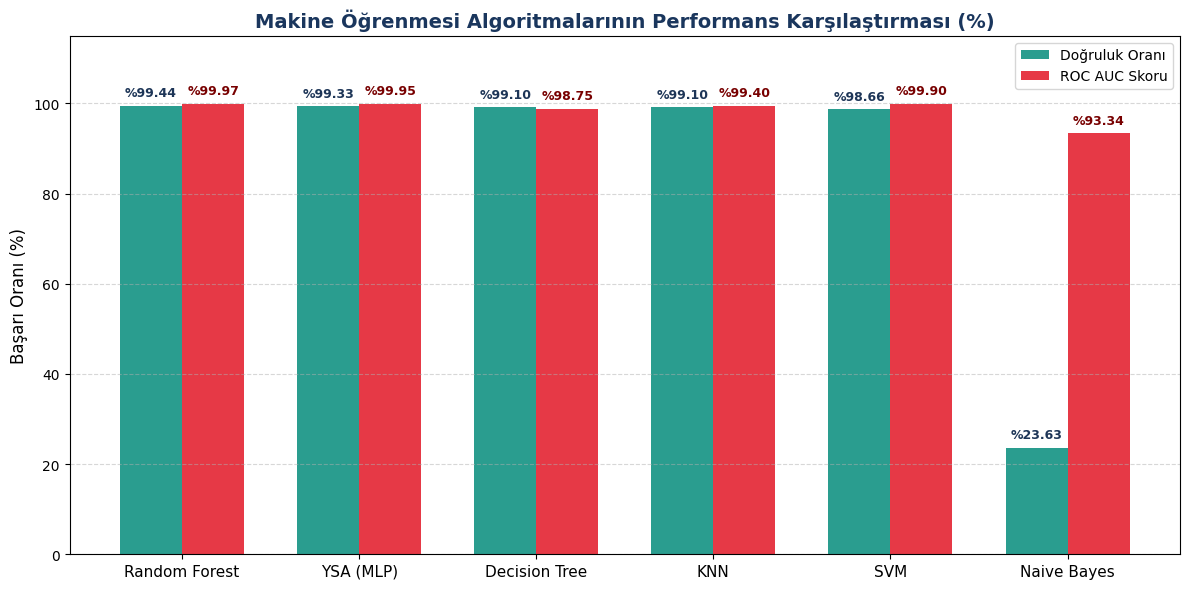


ÖZGÜN DEĞER KARŞILAŞTIRMASI (Random Forest):
Tüm Özellikler: %99.44 (ROC AUC: 0.9997)
Sadece İzinler: %98.88 (ROC AUC: 0.9989)
Sadece API Çağrıları: %100.00 (ROC AUC: 1.0000)


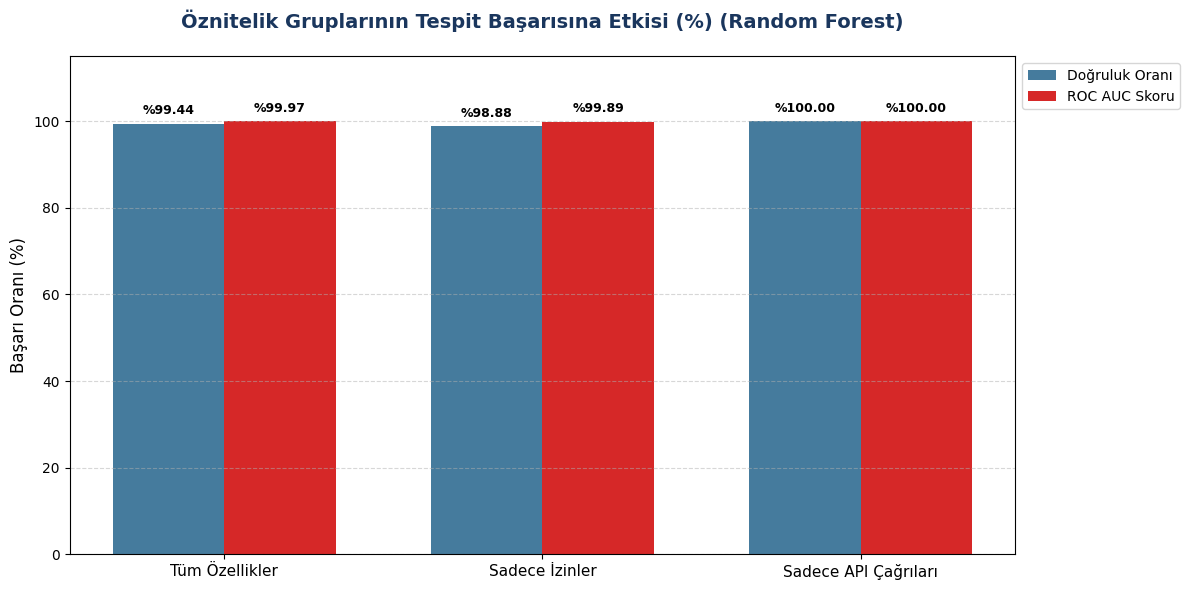

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Veri setini yükleme
dosya_yolu = 'TUANDROMD.csv'
df = pd.read_csv(dosya_yolu)

# Eksik verileri temizleme
df = df.dropna()

# Özellikler (X) ve Etiket (y) ayrımı
X = df.drop('Label', axis=1)
y = df['Label']

# Veriyi %80 eğitim, %20 test olarak bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Algoritmalar için ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Kullanacağımız algoritmaları tanımlama
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

modeller = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "YSA (MLP)": MLPClassifier(max_iter=300, random_state=42)
}

# Modelleri eğitme ve test etme
sonuclar_acc = {}
sonuclar_roc = {}

for isim, model in modeller.items():
    # Ölçeklendirme gerektiren algoritmalar (SVM, KNN, YSA)
    if isim in ["SVM", "KNN", "YSA (MLP)"]:
        model.fit(X_train_scaled, y_train)
        tahmin = model.predict(X_test_scaled)
        # ROC AUC için olasılık tahmini
        tahmin_proba = model.predict_proba(X_test_scaled)[:, 1]
        roc_skoru = roc_auc_score(y_test, tahmin_proba)

    else:
        model.fit(X_train, y_train)
        tahmin = model.predict(X_test)
        # ROC AUC için olasılık tahmini
        tahmin_proba = model.predict_proba(X_test)[:, 1]
        roc_skoru = roc_auc_score(y_test, tahmin_proba)

    dogruluk = accuracy_score(y_test, tahmin)
    sonuclar_acc[isim] = dogruluk
    sonuclar_roc[isim] = roc_skoru

    print(f"{isim}")
    print(f"Doğruluk Oranı (Accuracy): % {dogruluk*100:.2f}")
    print(f"ROC AUC Skoru: {roc_skoru:.4f}")
    print(classification_report(y_test, tahmin))
    print("\n")

# Özet Karşılaştırma Metni
print("GENEL KARŞILAŞTIRMA:")
sirali_sonuclar = sorted(sonuclar_acc.items(), key=lambda x: x[1], reverse=True)

for isim, dogruluk in sirali_sonuclar:
    print(f"{isim}: %{dogruluk*100:.2f} (ROC AUC: {sonuclar_roc[isim]:.4f})")

# GRAFİK OLUŞTURMA BÖLÜMÜ
isimler = [item[0] for item in sirali_sonuclar]
oranlar_acc = [item[1] * 100 for item in sirali_sonuclar]
oranlar_roc = [sonuclar_roc[item[0]] * 100 for item in sirali_sonuclar]

x = np.arange(len(isimler))
genislik = 0.35

plt.figure(figsize=(12, 6))

# Doğruluk Çubukları
cubuk_acc = plt.bar(x - genislik/2, oranlar_acc, genislik, label='Doğruluk Oranı', color='#2a9d8f')

# ROC AUC Çubukları
cubuk_roc = plt.bar(x + genislik/2, oranlar_roc, genislik, label='ROC AUC Skoru', color='#e63946')

plt.title('Makine Öğrenmesi Algoritmalarının Performans Karşılaştırması (%)', fontsize=14, fontweight='bold', color='#1a365d')
plt.ylabel('Başarı Oranı (%)', fontsize=12)
plt.ylim(0, 115)
plt.xticks(x, isimler, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

# Accuracy çubuklarının üzerine değer yazdırma
for bar in cubuk_acc:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'%{yval:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1d3557')

# ROC AUC çubuklarının üzerine değer yazdırma
for bar in cubuk_roc:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'%{yval:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#780000')

plt.tight_layout()
plt.show() # Grafiği ekrana yazdırma


# İzin ve API ayrımı
tum_sutunlar = df.columns.tolist()
api_cagrilari = [col for col in tum_sutunlar if col.startswith('L')]
izinler = [col for col in tum_sutunlar if not col.startswith('L') and col != 'Label']

X_izinler = df[izinler]
X_api = df[api_cagrilari]

senaryolar = {
    "Tüm Özellikler": X,
    "Sadece İzinler": X_izinler,
    "Sadece API Çağrıları": X_api
}

rf_model = RandomForestClassifier(random_state=42)
ozgunluk_acc = []
ozgunluk_roc = []

print("\nÖZGÜN DEĞER KARŞILAŞTIRMASI (Random Forest):")

for isim, X_data in senaryolar.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X_data, y, test_size=0.2, random_state=42)
    rf_model.fit(X_tr, y_tr)

    tahmin_oz = rf_model.predict(X_te)
    tahmin_proba_oz = rf_model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, tahmin_oz)
    roc = roc_auc_score(y_te, tahmin_proba_oz)

    ozgunluk_acc.append(acc * 100)
    ozgunluk_roc.append(roc * 100)

    print(f"{isim}: %{acc*100:.2f} (ROC AUC: {roc:.4f})")

# GRAFİK OLUŞTURMA BÖLÜMÜ (Özgün Değer)
isimler_oz = list(senaryolar.keys())
x_oz = np.arange(len(isimler_oz))

plt.figure(figsize=(12, 6))

# Doğruluk Çubukları
cubuk_acc_oz = plt.bar(x_oz - genislik/2, ozgunluk_acc, genislik, label='Doğruluk Oranı', color='#457b9d')

# ROC AUC Çubukları
cubuk_roc_oz = plt.bar(x_oz + genislik/2, ozgunluk_roc, genislik, label='ROC AUC Skoru', color='#d62828')

plt.title(
    label='Öznitelik Gruplarının Tespit Başarısına Etkisi (%) (Random Forest)',
    fontsize=14,
    fontweight='bold',
    color='#1a365d',
    loc='center',
    pad=20
)

plt.ylabel('Başarı Oranı (%)', fontsize=12)
plt.ylim(0, 115)
plt.xticks(x_oz, isimler_oz, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

for bar in cubuk_acc_oz:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'%{yval:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in cubuk_roc_oz:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'%{yval:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show() # Grafiği ekrana yazdırma

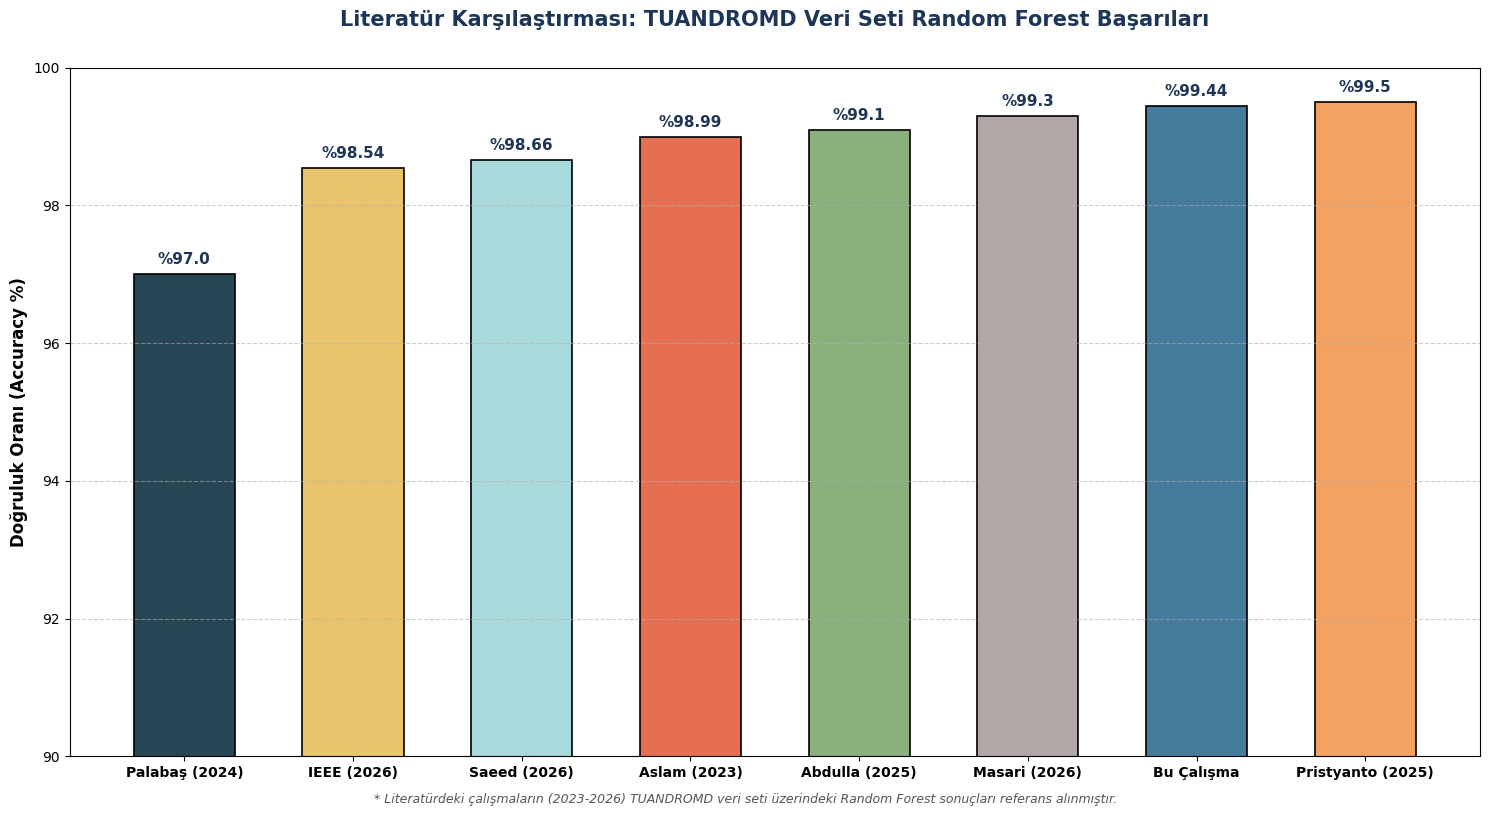

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

veriler = [
    ('Palabaş (2024)', 97.00),
    ('IEEE (2026)', 98.54),
    ('Saeed (2026)', 98.66),
    ('Aslam (2023)', 98.99),
    ('Abdulla (2025)', 99.10),
    ('Masari (2026)', 99.30),
    ('Bu Çalışma', 99.44),
    ('Pristyanto (2025)', 99.50)
]

calismalar = [x[0] for x in veriler]
dogruluk_oranlari = [x[1] for x in veriler]

renkler = ['#264653', '#e9c46a', '#a8dadc', '#e76f51', '#8ab17d', '#b1a7a6', '#457b9d', '#f4a261']

plt.figure(figsize=(15, 8))
x_konum = np.arange(len(calismalar))

# Çubuk grafiği
bars = plt.bar(x_konum, dogruluk_oranlari, color=renkler, width=0.6,
                edgecolor='black', linewidth=1.2)

# Grafik ayarları
plt.title('Literatür Karşılaştırması: TUANDROMD Veri Seti Random Forest Başarıları',
          fontsize=15, fontweight='bold', pad=30, color='#1d3557')
plt.ylabel('Doğruluk Oranı (Accuracy %)', fontsize=12, fontweight='bold')
plt.xticks(x_konum, calismalar, fontsize=10, fontweight='bold')
plt.ylim(90, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Değerlerin çubuk üzerine yazılması
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1,
             f'%{yval}', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color='#1d3557')

# Bilgi notu
plt.figtext(0.5, -0.01, "* Literatürdeki çalışmaların (2023-2026) TUANDROMD veri seti üzerindeki Random Forest sonuçları referans alınmıştır.",
            ha="center", fontsize=9, style='italic', color='#555555')

plt.tight_layout()
plt.show()

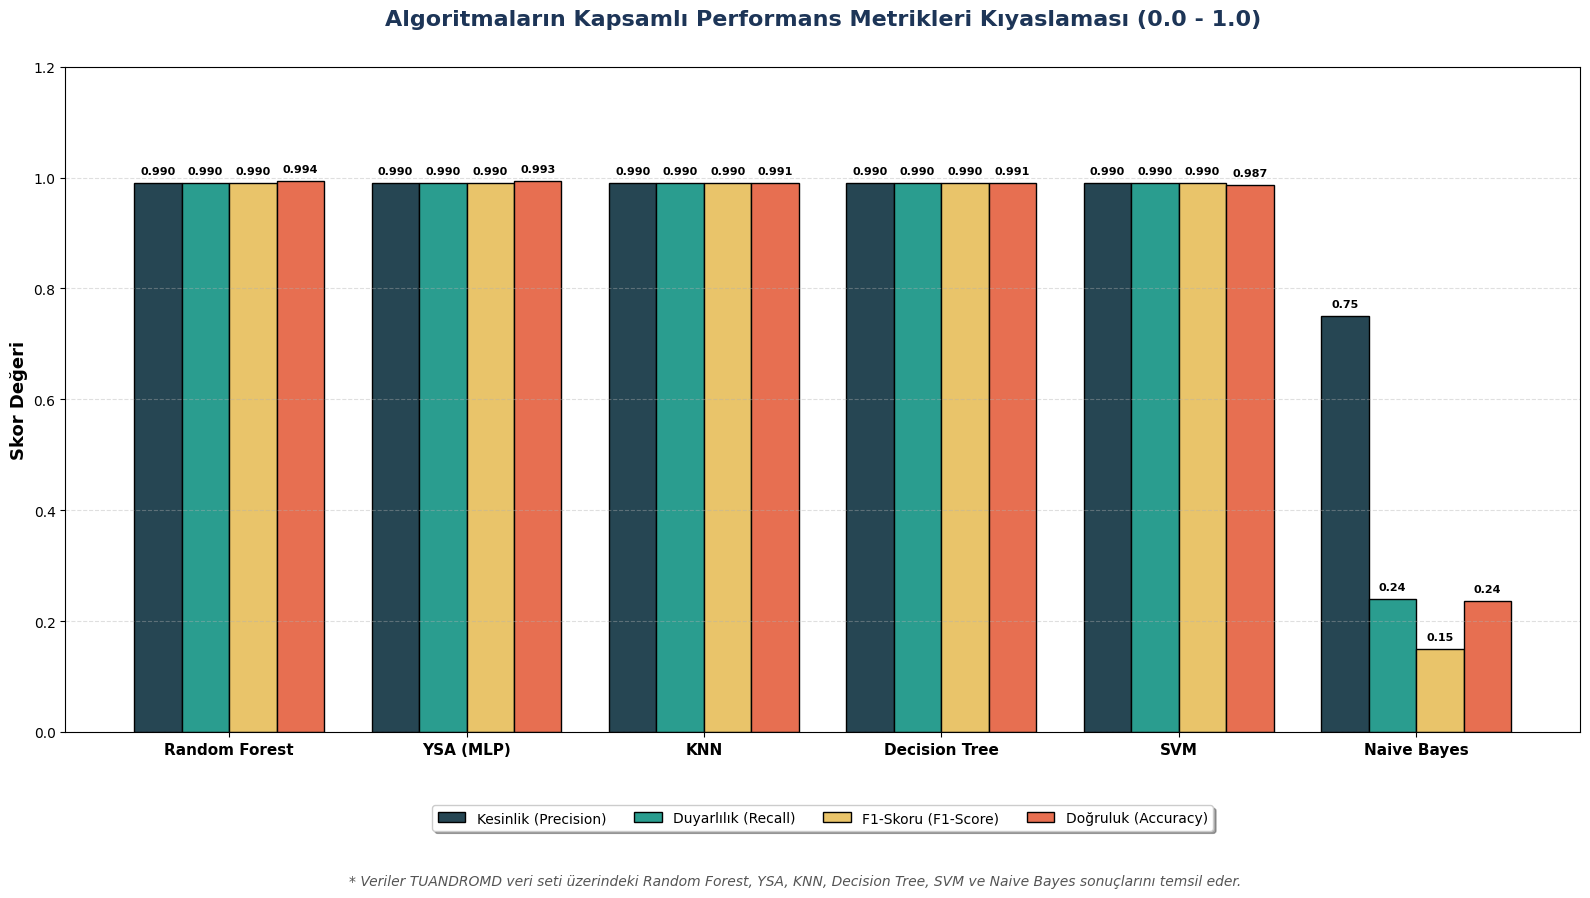

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. VERİLERİN TANIMLANMASI
algoritmalar = ['Random Forest', 'YSA (MLP)', 'KNN', 'Decision Tree', 'SVM', 'Naive Bayes']

# Değerler (0.0 - 1.0 aralığında)
accuracy_oranlari = [0.9944, 0.9933, 0.9910, 0.9910, 0.9866, 0.2363]
kesinlik_p = [0.99, 0.99, 0.99, 0.99, 0.99, 0.75]
duyarlilik_r = [0.99, 0.99, 0.99, 0.99, 0.99, 0.24]
f1_skoru_f = [0.99, 0.99, 0.99, 0.99, 0.99, 0.15]

x = np.arange(len(algoritmalar))
genislik = 0.20

plt.figure(figsize=(16, 9))

# 2. ÇUBUKLARIN OLUŞTURULMASI
rects1 = plt.bar(x - 1.5*genislik, kesinlik_p, genislik, label='Kesinlik (Precision)', color='#264653', edgecolor='black')
rects2 = plt.bar(x - 0.5*genislik, duyarlilik_r, genislik, label='Duyarlılık (Recall)', color='#2a9d8f', edgecolor='black')
rects3 = plt.bar(x + 0.5*genislik, f1_skoru_f, genislik, label='F1-Skoru (F1-Score)', color='#e9c46a', edgecolor='black')
rects4 = plt.bar(x + 1.5*genislik, accuracy_oranlari, genislik, label='Doğruluk (Accuracy)', color='#e76f51', edgecolor='black')

# 3. DEĞERLERİ ÇUBUKLARIN ÜZERİNE YAZDIRMA FONKSİYONU
def autolabel(rects):
    """Her bir barın üzerine yüksekliğini (değerini) metin olarak ekler."""
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.2f}' if height < 0.90 else f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold', rotation=0)

# Her grup için değerleri yazdır
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

# 4. GRAFİK AYARLARI
plt.title('Algoritmaların Kapsamlı Performans Metrikleri Kıyaslaması (0.0 - 1.0)',
          fontsize=16, fontweight='bold', pad=30, color='#1d3557')
plt.ylabel('Skor Değeri', fontsize=13, fontweight='bold')
plt.xticks(x, algoritmalar, fontsize=11, fontweight='bold')
plt.ylim(0, 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=True, shadow=True)

plt.figtext(0.5, 0.01, "* Veriler TUANDROMD veri seti üzerindeki Random Forest, YSA, KNN, Decision Tree, SVM ve Naive Bayes sonuçlarını temsil eder.",
            ha="center", fontsize=10, style='italic', color='#555555')

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

Veri seti başarıyla yüklendi.


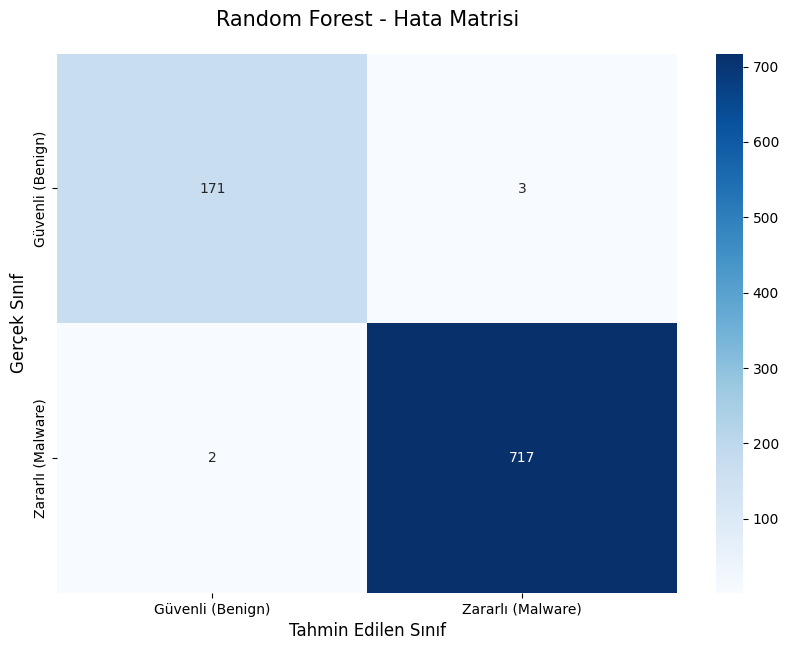

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# 1. Veri Setini Yükleme
try:
    df = pd.read_csv('TUANDROMD.csv').dropna()
    print("Veri seti başarıyla yüklendi.")
except FileNotFoundError:
    print("Hata: TUANDROMD.csv bulunamadı.")

# 2. Hazırlık
X = df.drop('Label', axis=1)
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Eğitimi (En Başarılı Algoritma: Random Forest)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 4. Hata Matrisi Görselleştirme
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Güvenli (Benign)', 'Zararlı (Malware)'],
            yticklabels=['Güvenli (Benign)', 'Zararlı (Malware)'])

plt.title("Random Forest - Hata Matrisi", fontsize=15, pad=20)
plt.xlabel("Tahmin Edilen Sınıf", fontsize=12)
plt.ylabel("Gerçek Sınıf", fontsize=12)
plt.show()

Veri seti yüklendi.


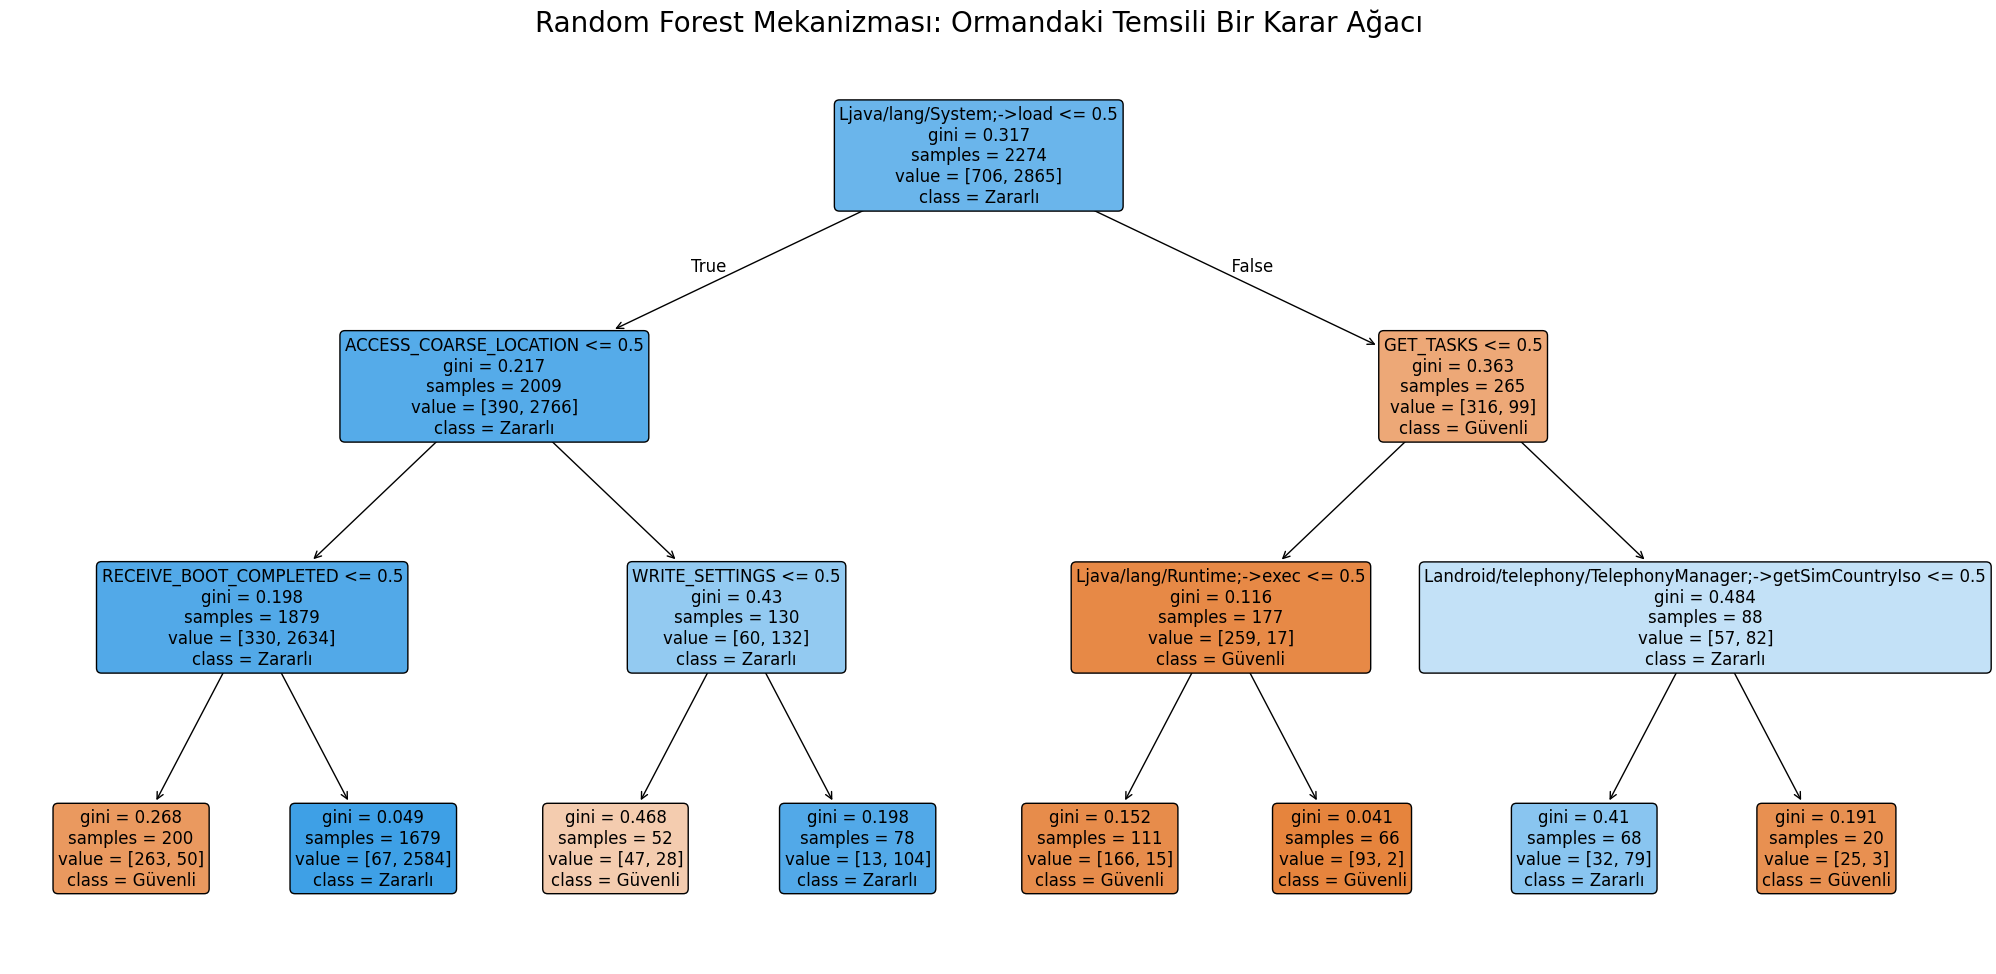

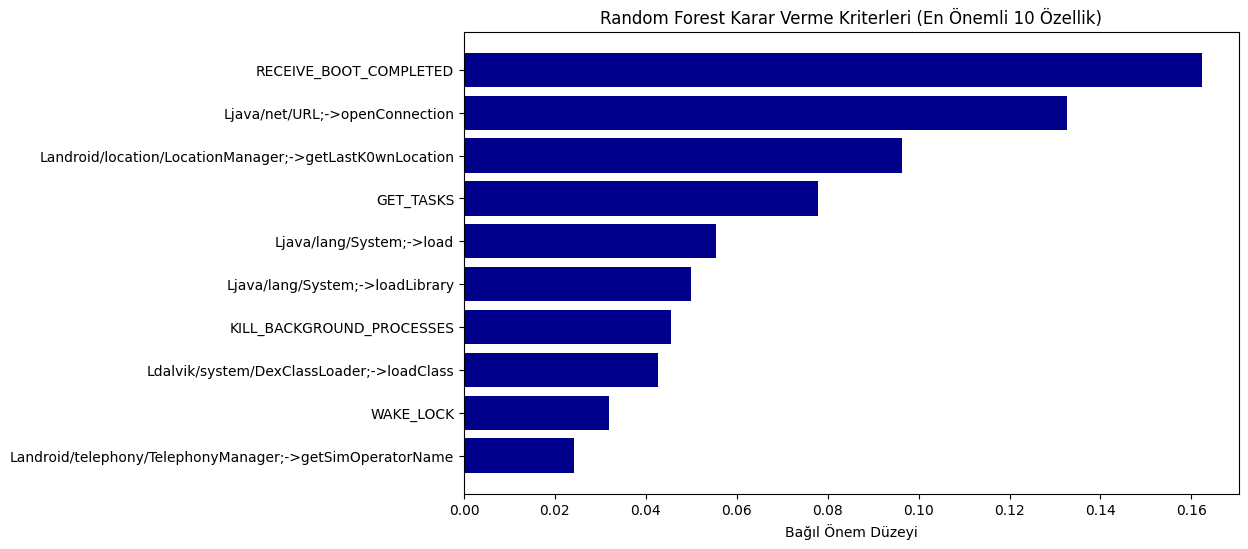

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

# 1. Veri Setini Yükleme
try:
    df = pd.read_csv('TUANDROMD.csv').dropna()
    print("Veri seti yüklendi.")
except:
    print("Lütfen TUANDROMD.csv dosyasını yükleyin.")

X = df.drop('Label', axis=1)
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Random Forest Modelini Eğitme
rf_model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Mekanizma 1: Ormandaki İlk Ağacı Görselleştirme
# Random Forest içindeki 100 ağaçtan sadece bir tanesinin mantığını görüyoruz.
plt.figure(figsize=(25, 12))
plot_tree(rf_model.estimators_[0], # İlk ağacı seçiyoruz
          feature_names=X.columns,
          class_names=['Güvenli', 'Zararlı'],
          filled=True, rounded=True, fontsize=12)
plt.title("Random Forest Mekanizması: Ormandaki Temsili Bir Karar Ağacı", fontsize=20)
plt.show()

# 4. Mekanizma 2: Öznitelik Önemi (Hangi özellik kararı en çok etkiliyor?)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:] # En önemli 10 özellik

plt.figure(figsize=(10, 6))
plt.title("Random Forest Karar Verme Kriterleri (En Önemli 10 Özellik)")
plt.barh(range(len(indices)), importances[indices], color='darkblue', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Bağıl Önem Düzeyi')
plt.show()